In [1]:
import sys
sys.path.append("../src")

from load_data import load_dataset
from transform import clean_columns, convert_date, add_total_sale
from analysis import unique_values, missing_values, frequency_distribution, basic_info
from warehouse import *
from database import connect_db, load_table, verify_connection
from visualization import *

## Dataset

In [2]:
df = load_dataset("../data/customer_shopping_data.csv")

In [3]:
basic_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB
None
                age      quantity         price
count  99457.000000  99457.000000  99457.000000
mean      43.427089      3.003429    689.256321
std       14.990054      1.413025    941.184567
min       18.000000      1.000000      5.230000
25%       30.000000      2.000000     45.450

In [4]:
unique_values(df)

{'invoice_no': 99457,
 'customer_id': 99457,
 'gender': 2,
 'age': 52,
 'category': 8,
 'quantity': 5,
 'price': 40,
 'payment_method': 3,
 'invoice_date': 797,
 'shopping_mall': 10}

In [5]:
missing_values(df)

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

In [6]:
frequency_distribution(df, "category")

category
Clothing           34487
Cosmetics          15097
Food & Beverage    14776
Toys               10087
Shoes              10034
Souvenir            4999
Technology          4996
Books               4981
Name: count, dtype: int64

In [7]:
frequency_distribution(df, "invoice_no")

invoice_no
I138884    1
I317333    1
I127801    1
I173702    1
I337046    1
          ..
I219422    1
I325143    1
I824010    1
I702964    1
I232867    1
Name: count, Length: 99457, dtype: int64

In [8]:
frequency_distribution(df, "payment_method")

payment_method
Cash           44447
Credit Card    34931
Debit Card     20079
Name: count, dtype: int64

# ETL

1. Como primer paso se hizo la transformación de la columna `invoice_date` a un formato de fecha utilizando `pd.to_datetime()`. Esto se hizo para asegurar que los datos de fecha estén en un formato consistente y puedan ser utilizados para análisis posteriores. Se utilizó el parámetro `format='mixed'` para manejar diferentes formatos de fecha, `dayfirst=True` para interpretar correctamente las fechas con el día antes del mes, y `errors='coerce'` para convertir cualquier valor no convertible a NaT (Not a Time).

In [9]:
df = convert_date(df)

2. Como segundo paso se creo una nueva columna en el DataFrame llamada `total_amount`, que se calculó multiplicando la cantidad (`quantity`) por el precio (`price`). Esta nueva columna representa el monto total de cada transacción.

In [10]:
df = add_total_sale(df)

3. Como tercer paso se creo una nueva tabla llamada `table_customer` que contiene información única de cada cliente, incluyendo su `customer_id`, `gender` y `age`.

In [11]:
table_customer = create_customer_dimension(df)

4. Como cuarto paso se creo una nueva tabla llamada `table_category`, la cual se puso para que no tenga duplicados y asi tener solo una fila por cada categoria, luego se hizo un reseteo de index, el cual se le asigno a la columna `category_id`.

In [12]:
table_category = create_category_dimension(df)

5.  Como quinto paso se creo una nueva tabla llamada `table_payment`, la cual se puso para que no tenga duplicados y asi tener solo una fila por cada tipo de pago, luego se hizo un reseteo de index, el cual se le asigno a la columna `payment_id`.

In [13]:
table_payment = create_payment_dimension(df)

6.  Como sexto paso se creo una nueva tabla llamada `table_mall`, la cual se puso para que no tenga duplicados y asi tener solo una fila por cada centro comercial, luego se hizo un reseteo de index, el cual se le asigno a la columna `mall_id`.

In [14]:
table_mall = create_mall_dimension(df)

7. Como séptimo paso se creo una nueva tabla llamada `table_date`, la cual se puso para que no tenga duplicados y asi tener solo una fila por cada fecha, luego se hizo un reseteo de index, el cual se le asigno a la columna `date_id`. Ademas, se crea una columna por dia, mes y año, para facilitar el análisis temporal de los datos.

In [15]:
table_date = create_date_dimension(df)

8. Como octavo paso se hizo un merge de las tablas `table_category`, `table_mall` y `table_payment` con el DataFrame original `df` utilizando la función `merge()`. Esto se hizo para agregar la información de categoría, centro comercial y método de pago a cada transacción en el DataFrame original. Luego se creó una nueva columna llamada `date_id`, que se calculó a partir de la columna `invoice_date` utilizando el formato 'YYYYMMDD' y se convirtió a tipo entero.

In [16]:
table_sales = create_sales_fact(df, table_category, table_payment, table_mall)

## Conexión BD

In [17]:
engine = connect_db()

In [18]:
verify_connection(engine)

Conexión exitosa a la base de datos


In [19]:
# cargar las tablas de dimensiones al motor de base de datos
load_table(table_customer, "table_customer", engine)
load_table(table_category, "table_category", engine)
load_table(table_payment, "table_payment", engine)
load_table(table_mall, "table_mall", engine)
load_table(table_date, "table_date", engine)
# cargar la tabla de hechos al motor de base de datos
load_table(table_sales, "table_sales", engine)


Tabla table_customer cargada correctamente
Tabla table_category cargada correctamente
Tabla table_payment cargada correctamente
Tabla table_mall cargada correctamente
Tabla table_date cargada correctamente
Tabla table_sales cargada correctamente


# Análisis Descriptivo y Visualización de Datos 

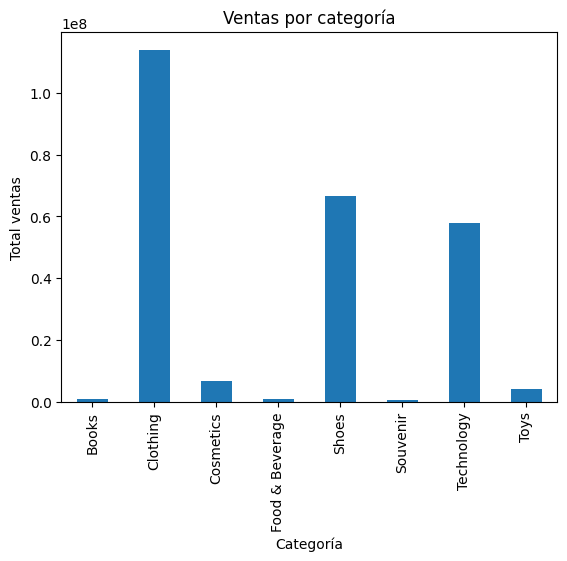

In [20]:
# ventas por categoría
sales_by_category(df)

Podemos observar que la vestimenta es la categoria que más prefieren comprar los clientes. El negocio podria beneficiarse más si fortalce el inventario en esta categoria.

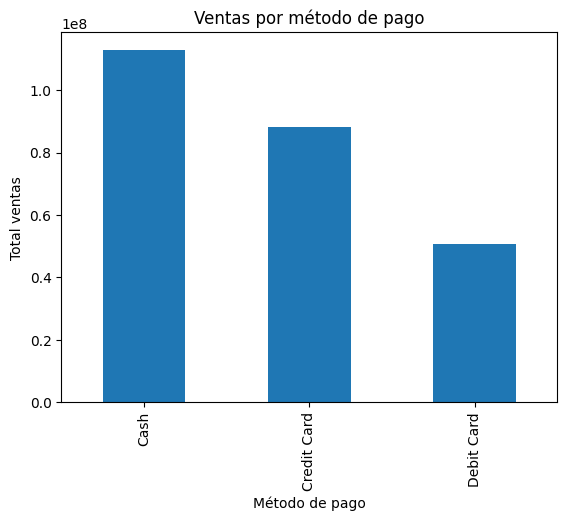

In [21]:
sales_by_payment_method(df)

El método de pago más habitual es el efectivo. mientras que las tarjetas de credito le siguen con una participación importante y vemos las tajetas debito presentando el menor número de transacciones.

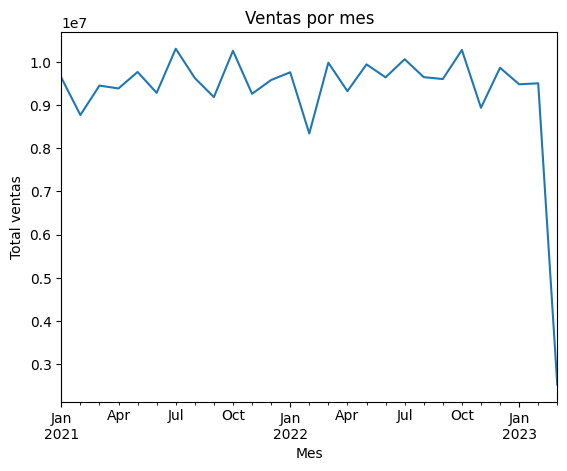

In [22]:
sales_by_month(df)

Podemos identificar que al inicio del año hay una disminución en las ventas. Para solucionar esto, se podria crear promociones y eventos para mejorar estos picos. Pero tambien se observa que en el fin de año se aumenta el consumo en las temporadas festivas. 

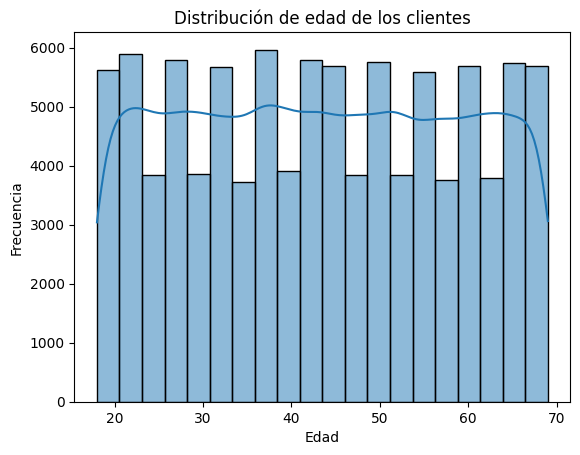

In [23]:
distribution_age(df)

Podemos ver que que los consumidores mas frecuentes se encuentran entre lo 20 y 40 años, esto nos permite identificar el público objetivo.

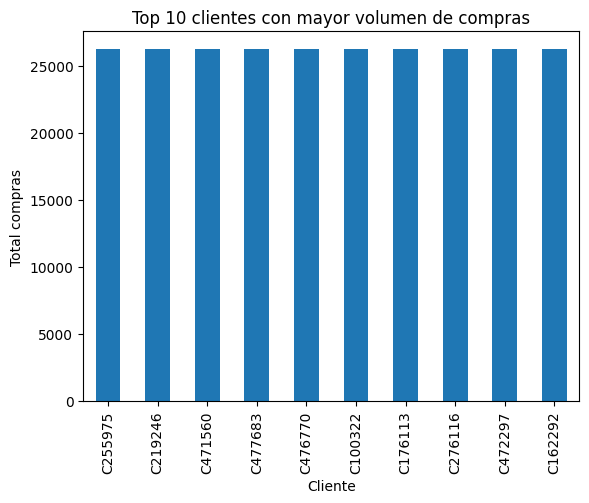

In [24]:
top_customers(df)

Un pequeño grupo de clientes representa una proporción significativa de las ventas, lo que indica que el negocio podría beneficiarse de estrategias de fidelización.

<Figure size 640x480 with 0 Axes>

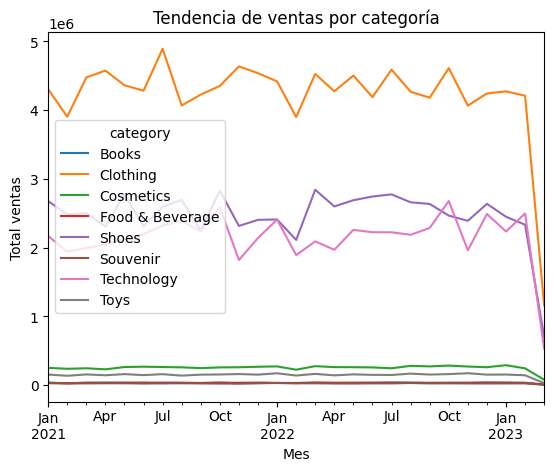

In [25]:
category_month(df)

El grafico anterior muestra las ventas por categoría a lo largo del tiempo, lo que permite identificar tendencias estacionales y patrones de compra. Por ejemplo, se puede observar un aumento en las ventas de ropa durante ciertas épocas del año, como las temporadas de vacaciones o eventos especiales. Esta información es valiosa para planificar el inventario y las promociones de manera más efectiva.

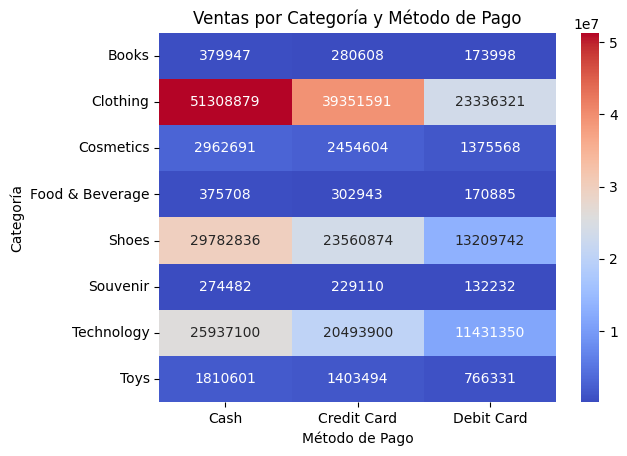

In [26]:
sale_category(df)

Este grafico nos muestra la distribución de las ventas por método de pago y categoria, podemos observar que el efectivo es el método de pago más utilizado en todas las categorías, seguido por las tarjetas de crédito. Sin embargo, en la categoría de tecnología, las tarjetas de crédito tienen una participación más significativa en comparación con otras categorías.

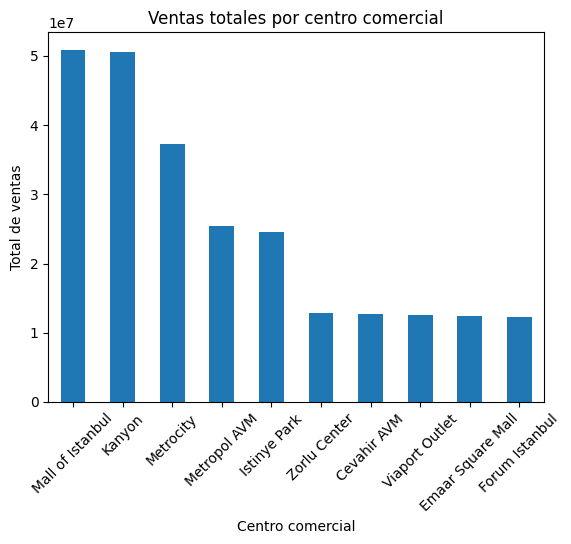

In [27]:
sales_by_mall(df)

En este grafico se logra observar que los tres centros comerciales que mas vende son el Mall of Istanbul, Kanyon y Metrocity.

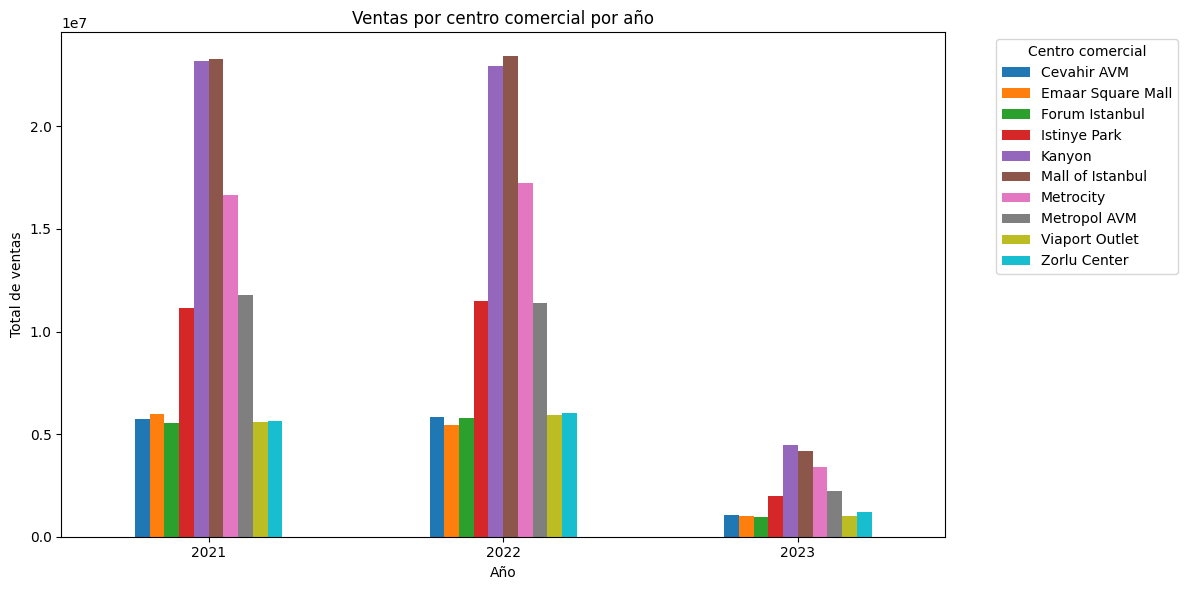

In [28]:
top_malls_by_year(df)

En el grafico anterior se muestra las ventas que tuvieron los centros comerciales en los años 2021, 2022 y 2023, se puede observar que en estos años que siempre hubieron dos centros comerciales que lideran las ventas, el kanoy y el mall of istanbul.